In [9]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
# 1. Load the dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target # This is our 'y' (Price in $100,000s)
print("Dataset Overview:")
print(df.head())
print("\nBasic Statistics:")
print(df.describe())

Dataset Overview:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900   

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
# Define Features and Target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
# 1. Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
# 2. Scale: Standardize features (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Absolute Error: ${mae * 100000:.2f}")
print(f"R-Squared Score: {r2:.2f}")

Mean Absolute Error: $53320.01
R-Squared Score: 0.58


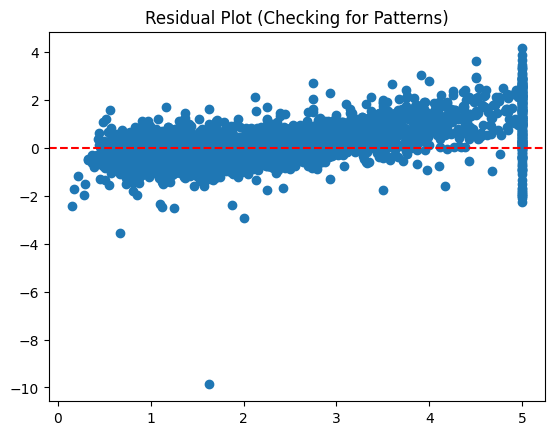

In [12]:
import matplotlib.pyplot as plt
residuals = y_test - predictions
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (Checking for Patterns)")
plt.show()